# **Machine Learning-2- EasyVisa**

**Context**

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

**Objective**

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having a higher chance of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You, as a data scientist at EasyVisa, have to analyze the data provided and, with the help of a classification model:

1. Facilitate the process of visa approvals.
2. Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


**Data Description**

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.


*   case_id: ID of each visa application
*  continent: Information of continent the employee

*   education_of_employee: Information of education of the employee
*   has_job_experience: Does the employee have any job experience? Y= Yes; N = No

*   requires_job_training: Does the employee require any job training? Y = Yes; N = No
*   no_of_employees: Number of employees in the employer's company

*   yr_of_estab: Year in which the employer's company was established
*   region_of_employment: Information of foreign worker's intended region of employment in the US.

*   prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
*   unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.

*   full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
*   case_status: Flag indicating if the Visa was certified or denied













## **Importing necessary libraries and data**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

**Loading Data**

In [ ]:
Visa = pd.read_csv("/EasyVisa.csv")

In [ ]:
data = Visa.copy()

**Overview**

In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


**Shape of data**

In [ ]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 25480 rows and 12 columns.


**Check data types of all columns**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB




*   prevailing_wage is float type, no_of_employees and yr_of_estab int type and rest are object type.

**Statistical Summary**

In [ ]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.000,NaN,NaN,NaN,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,NaN,NaN,NaN,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.000,NaN,NaN,NaN,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Checking for duplicate values**

In [ ]:
data.duplicated().sum()

np.int64(0)



*   There are no duplicate values in the data.



**Checking for missing value**

In [ ]:
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0




*   There are no missing values in the data.



**Data preprocessing**

Let's check the count of each unique category in each of the categorical variables.

In [ ]:
cat_col = list(data.select_dtypes("object").columns)
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

The case_id column will not add any value to our analysis so let's drop it before we move forward.

In [ ]:
data = data.drop(["case_id"], axis=1)

In [ ]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


**Exploratory Data Analysis (EDA)**

**Univariate Analysis**

**Continent**

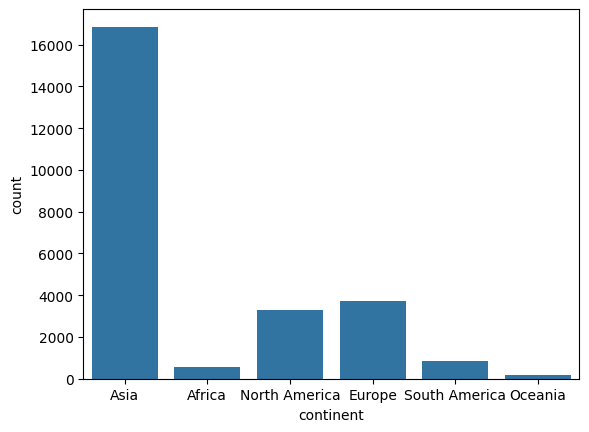

In [ ]:
sns.countplot(data,x='continent')
plt.show()



*   Over 16000 employees are from asia and below 4000 employees are from each of africa, north america, europe, south america and oceania.



**Education**

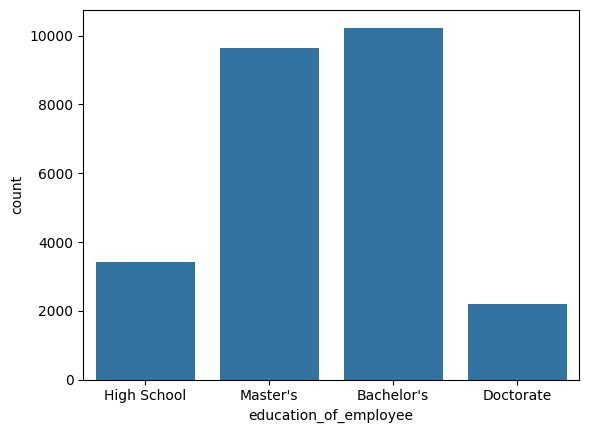

In [ ]:
sns.countplot(data,x='education_of_employee')
plt.show()



*   Majority of employees are has either has bachelor's degree or master's degree.



**Region of employment**

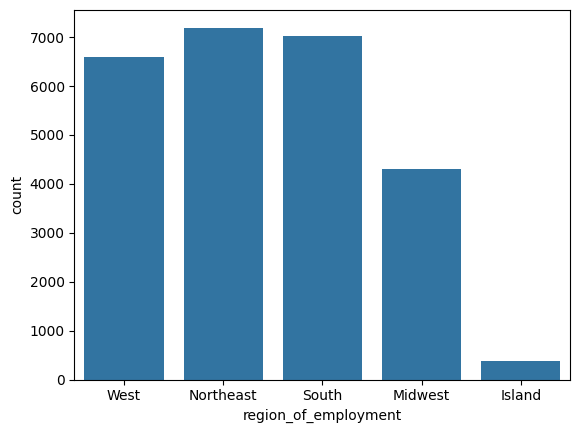

In [ ]:
sns.countplot(data,x='region_of_employment')
plt.show()



*   Majority of employers are from west, Northeast and south region.



**Unit of wage**

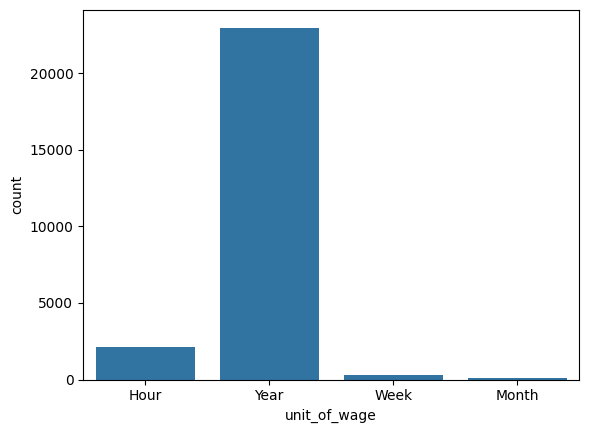

In [ ]:
sns.countplot(data,x='unit_of_wage')
plt.show()



*   Maximum employees work on yearly wages.



**Employee count**

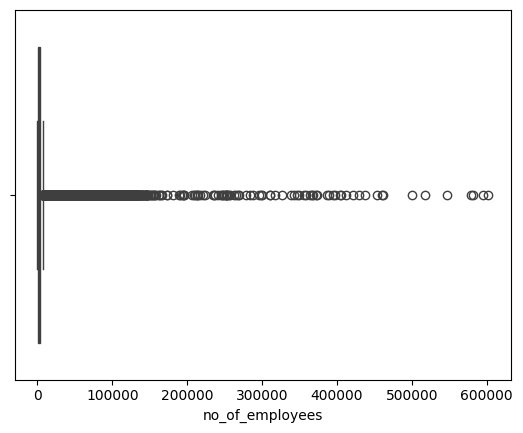

In [ ]:
sns.boxplot(data,x='no_of_employees')
plt.show()



*   The distribution is positively skewed.




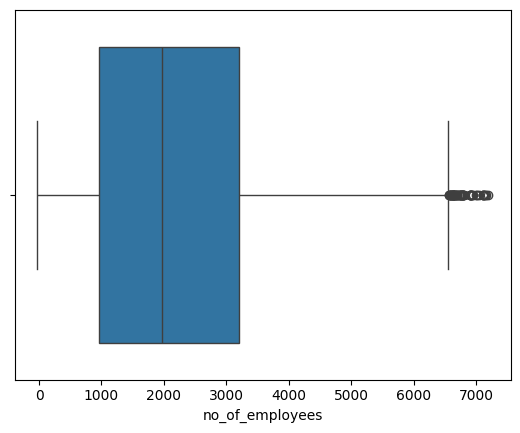

In [ ]:
Q1 = data['no_of_employees'].quantile(0.25)
Q3 = data['no_of_employees'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['no_of_employees'] >= lower_bound) & (data['no_of_employees'] <= upper_bound)]
sns.boxplot(data,x='no_of_employees')
plt.show()

**Prevailing wage**

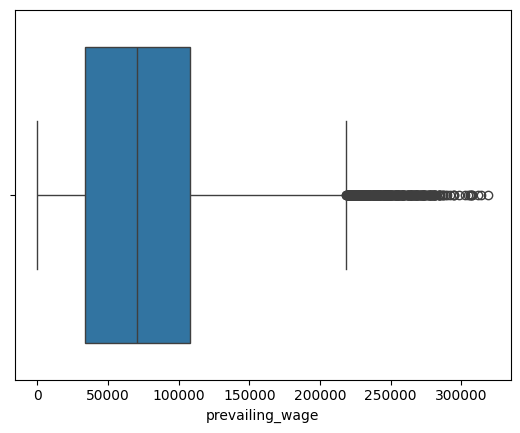

In [ ]:
sns.boxplot(data,x='prevailing_wage')
plt.show()

*   The distribution is positively skewed.

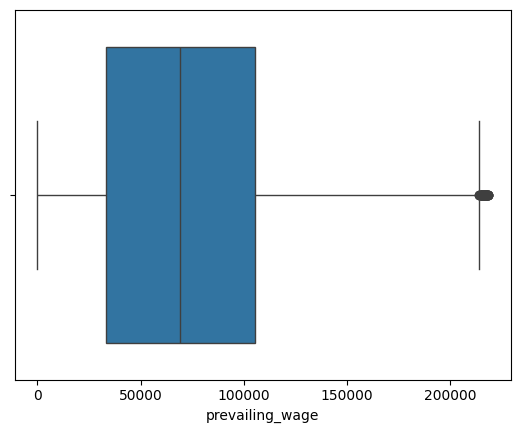

In [ ]:
Q1 = data['prevailing_wage'].quantile(0.25)
Q3 = data['prevailing_wage'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['prevailing_wage'] >= lower_bound) & (data['prevailing_wage'] <= upper_bound)]
sns.boxplot(data,x='prevailing_wage')
plt.show()

**Job Experience**

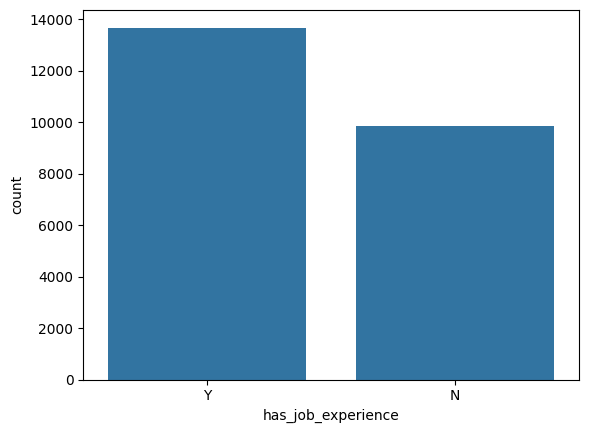

In [ ]:
sns.countplot(data,x='has_job_experience')
plt.show()



*   More than 13000 employees has job experience and around 10000 employees do not have job experience.




**Training**

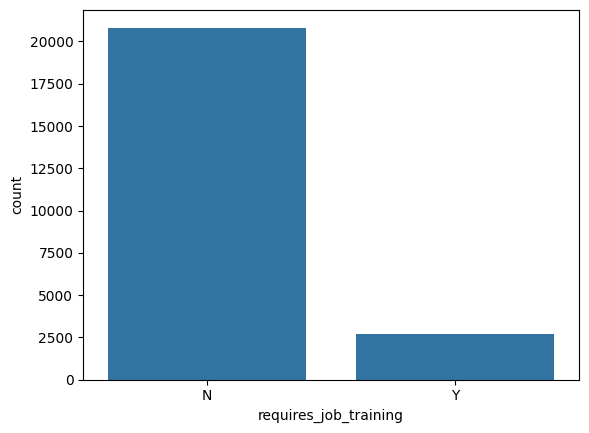

In [ ]:
sns.countplot(data,x='requires_job_training')
plt.show()



*   More than 20000 employees do not requires job training and 2500 employees required job training.



**Job type**

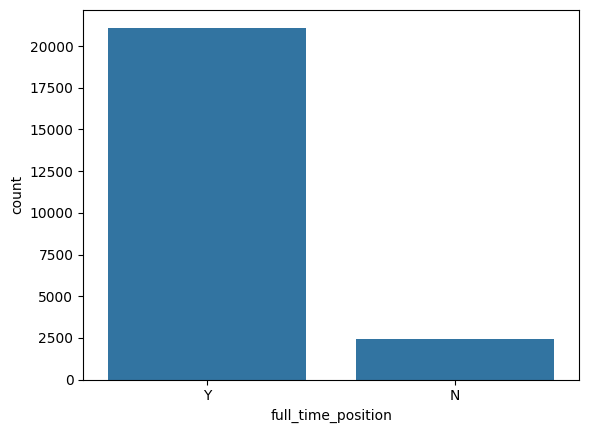

In [ ]:
sns.countplot(data,x='full_time_position')
plt.show()



*   More than 20000 jobs are full time jobs.



**Status**

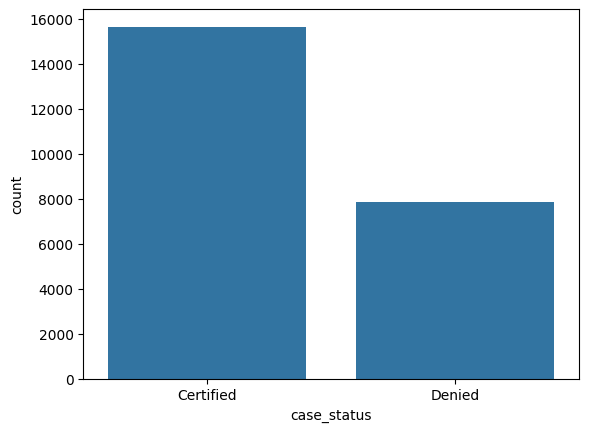

In [ ]:
sns.countplot(data,x='case_status')
plt.show()



*   More than 15000 employees has certified visa whereas around 8000 employee's visa has got denied.



**Bivariate Analysis**

**Scater plot**

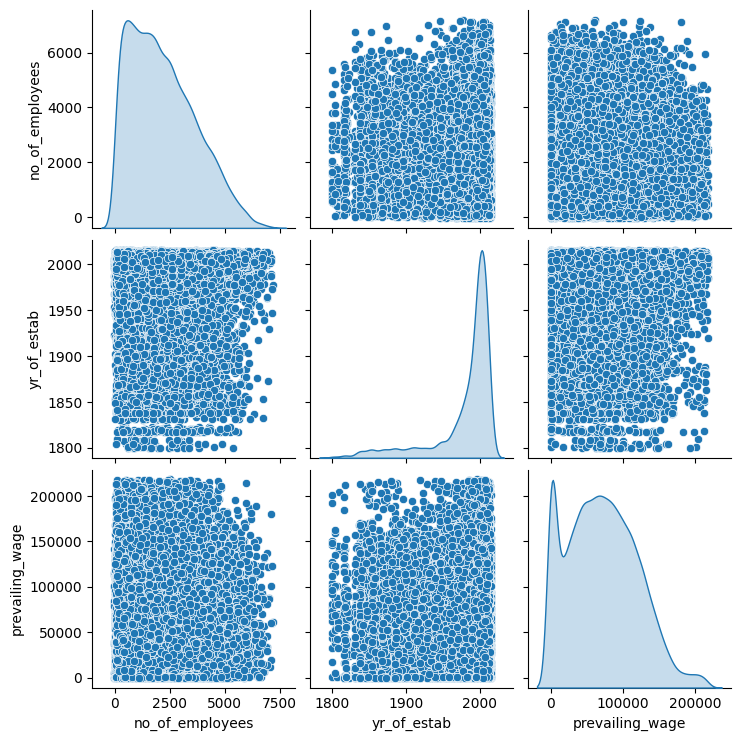

In [ ]:
sns.pairplot(data, diag_kind="kde")
plt.show()

**Continent vs Status**

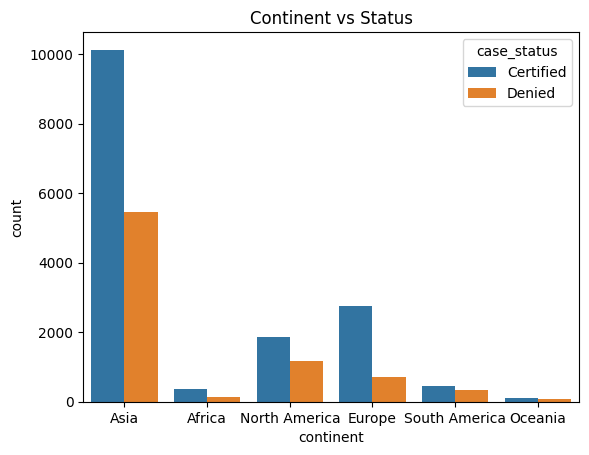

In [ ]:
sns.countplot(data,x='continent', hue= 'case_status')
plt.title('Continent vs Status')
plt.show()

**Education vs Status**

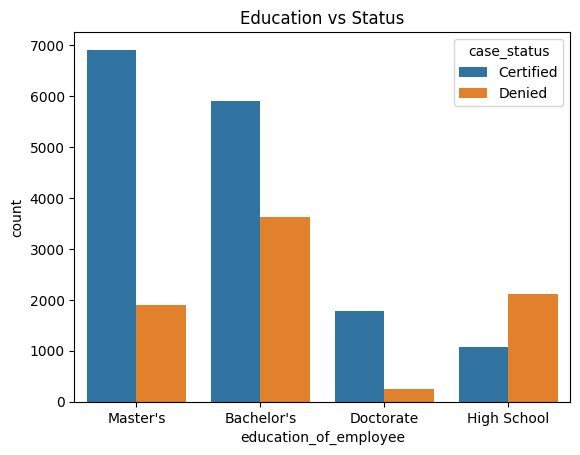

In [ ]:
sns.countplot(data,x='education_of_employee', hue= 'case_status')
plt.title('Education vs Status')
plt.show()



*   From this plot we can say that higher the education of employee higher the chances the employee get certified visa.



**Job experience vs Status**

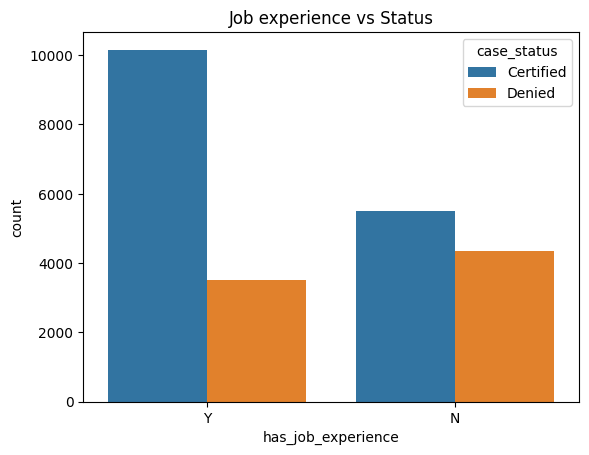

In [ ]:
sns.countplot(data,x='has_job_experience', hue= 'case_status')
plt.title('Job experience vs Status')
plt.show()



*   Employees having job experience has higher chances of getting certified visa.


**Training required vs Status**

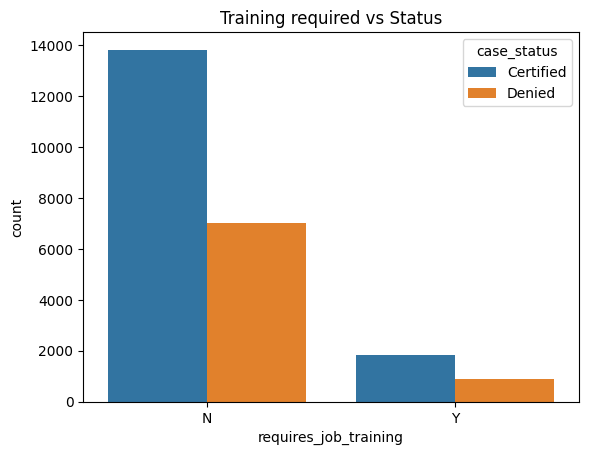

In [ ]:
sns.countplot(data,x='requires_job_training', hue= 'case_status')
plt.title('Training required vs Status')
plt.show()

**Region of employment vs Status**

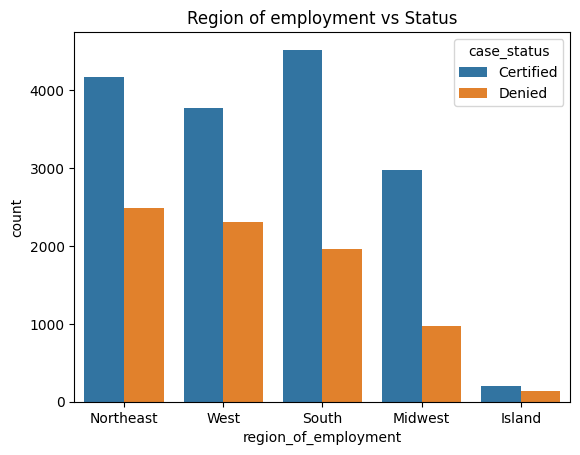

In [ ]:
sns.countplot(data,x='region_of_employment', hue= 'case_status')
plt.title('Region of employment vs Status')
plt.show()



*   Comparitively south and midwest region has less chances of denial of visa.



**Job type vs Status**

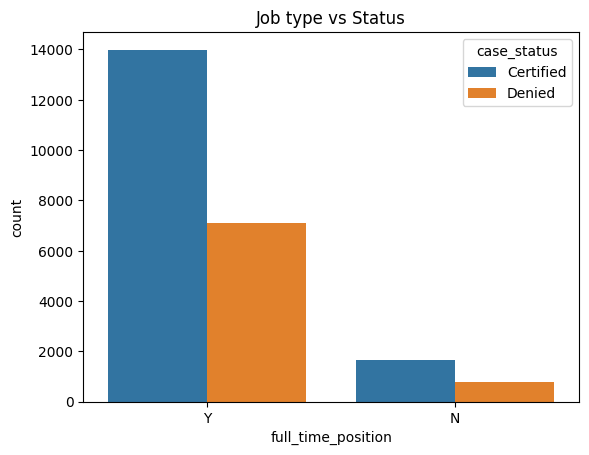

In [ ]:
sns.countplot(data,x='full_time_position', hue= 'case_status')
plt.title('Job type vs Status')
plt.show()

**Unit of wage vs Status**

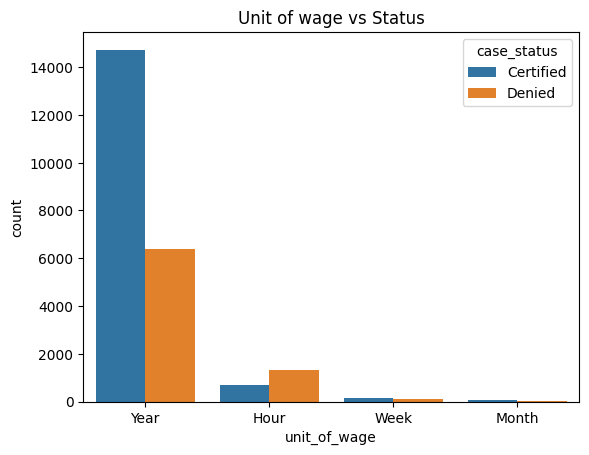

In [ ]:
sns.countplot(data,x='unit_of_wage', hue= 'case_status')
plt.title('Unit of wage vs Status')
plt.show()



*  Yearly based wages are higher chances of getting certified visa.
*  Hourly based wages are lesser chances of getting certified visa.




**Data preprocessing (Cont.)**

In [ ]:
data.shape

(23519, 11)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23519 entries, 1 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              23519 non-null  object 
 1   education_of_employee  23519 non-null  object 
 2   has_job_experience     23519 non-null  object 
 3   requires_job_training  23519 non-null  object 
 4   no_of_employees        23519 non-null  int64  
 5   yr_of_estab            23519 non-null  int64  
 6   region_of_employment   23519 non-null  object 
 7   prevailing_wage        23519 non-null  float64
 8   unit_of_wage           23519 non-null  object 
 9   full_time_position     23519 non-null  object 
 10  case_status            23519 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.2+ MB


In [ ]:
data = pd.get_dummies(
    data,
    columns=data.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,
)

data = data.astype(float)

In [ ]:
data.head()

,no_of_employees,yr_of_estab,prevailing_wage,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y,case_status_Denied
1,2412.000,2002.000,83425.650,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000
3,98.000,1897.000,83434.030,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,1.000,1.000
4,1082.000,2005.000,149907.390,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000
5,2339.000,2012.000,78252.140,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000
6,4985.000,1994.000,53635.390,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000


In [ ]:
data.shape

(23519, 22)

**Splitting data into train, validation and test set**

In [ ]:
X = data.drop(["case_status_Denied"], axis=1)
y = data["case_status_Denied"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(14111, 21) (4704, 21) (4704, 21)


In [ ]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 14111
Number of rows in validation data = 4704
Number of rows in test data = 4704


**Model building**

**Model evaluation criterion**

As OFLC hired us we should be more causious about certifing visa.

1. Model can make wrong predictions as:
   1. False Positive (FP) :- Visa granted to an ineligible candidate → risk to the system (security, fraud, misuse)
   2. False Negative (FN) :- Denying an eligible candidate → unfairness, lost opportunity.
2. Which case is more important?
   Granting a visa to an ineligible person (FP) is much worse than denying an eligible one (FN). So False Positives are more costly.
3. How to reduce this loss i.e need to reduce False Positives?
   OFLC would want Precision to be maximized, greater the Precision lesser the chances of false positives.

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

**Model building (Original data)**

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = precision_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = precision_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9930446488669509
Random forest: 1.0
GBM: 0.6787292817679558
Adaboost: 0.6611698817672682
dtree: 1.0

Validation Performance:

Bagging: 0.5978552278820375
Random forest: 0.6163166397415186
GBM: 0.6652858326429163
Adaboost: 0.6505914467697907
dtree: 0.4815051020408163


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = precision_score(y_train, model.predict(X_train))
    scores_val = precision_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9930, Validation Score: 0.5979, Difference: 0.3952
Random forest: Training Score: 1.0000, Validation Score: 0.6163, Difference: 0.3837
GBM: Training Score: 0.6787, Validation Score: 0.6653, Difference: 0.0134
Adaboost: Training Score: 0.6612, Validation Score: 0.6506, Difference: 0.0106
dtree: Training Score: 1.0000, Validation Score: 0.4815, Difference: 0.5185


AdaBoost model has the best performance followed by GBM as per the validation performance.

**Model building (Oversampled data)**

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 4725
Before Oversampling, counts of label 'No': 9386 

After Oversampling, counts of label 'Yes': 9386
After Oversampling, counts of label 'No': 9386 

After Oversampling, the shape of train_X: (18772, 21)
After Oversampling, the shape of train_y: (18772,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = precision_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = precision_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9959549579096971
Random forest: 1.0
GBM: 0.8509034342467393
Adaboost: 0.8159806295399515
dtree: 1.0

Validation Performance:

Bagging: 0.5815722738799662
Random forest: 0.6012223071046601
GBM: 0.6604987932421561
Adaboost: 0.6168831168831169
dtree: 0.49002493765586036


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = precision_score(y_train_over, model.predict(X_train_over))
    scores_val = precision_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9960, Validation Score: 0.5816, Difference: 0.4144
Random forest: Training Score: 1.0000, Validation Score: 0.6012, Difference: 0.3988
GBM: Training Score: 0.8509, Validation Score: 0.6605, Difference: 0.1904
Adaboost: Training Score: 0.8160, Validation Score: 0.6169, Difference: 0.1991
dtree: Training Score: 1.0000, Validation Score: 0.4900, Difference: 0.5100


 GBM has the best performance followed by AdaBoost model as per the validation performance.

**Model building (Undersampled data)**

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 4725
Before Under Sampling, counts of label 'No': 9386 

After Under Sampling, counts of label 'Yes': 4725
After Under Sampling, counts of label 'No': 4725 

After Under Sampling, the shape of train_X: (9450, 21)
After Under Sampling, the shape of train_y: (9450,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = precision_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = precision_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9879931389365352
Random forest: 1.0
GBM: 0.72319309600863
Adaboost: 0.7030977312390925
dtree: 1.0

Validation Performance:

Bagging: 0.5093432995194874
Random forest: 0.5264400377714825
GBM: 0.5613602759980286
Adaboost: 0.53681592039801
dtree: 0.4606227106227106


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = precision_score(y_train_un, model.predict(X_train_un))
    scores_val = precision_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9880, Validation Score: 0.5093, Difference: 0.4786
Random forest: Training Score: 1.0000, Validation Score: 0.5264, Difference: 0.4736
GBM: Training Score: 0.7232, Validation Score: 0.5614, Difference: 0.1618
Adaboost: Training Score: 0.7031, Validation Score: 0.5368, Difference: 0.1663
dtree: Training Score: 1.0000, Validation Score: 0.4606, Difference: 0.5394




*    GBM has the best performance followed by AdaBoost model as per the validation performance.

*   After building 15 models, it was observed that both the GBM and Adaboost models, trained on an original dataset, as well as the GBM model trained on an oversampled dataset, exhibited strong performance on both the training and validation datasets.
*   Lets tune models to improve their performance.


*   We will tune these 3 models using the same data (original or oversampled) as we trained them on before.






**Hyperparameter tuning**

**Tuning Gradient Boosting model with Original Data**

In [ ]:
#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.precision_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1, 'n_estimators': np.int64(125), 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7034376804532931:


In [ ]:
tuned_gbm1 = GradientBoostingClassifier(
    random_state=1,
    subsample=1,
    n_estimators=125,
    max_features=1,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm1.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=1, n_estimators=125,
                           random_state=1, subsample=1)

In [ ]:
gbm1_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train, y_train)
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.719,0.275,0.704,0.395


In [ ]:
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.713,0.264,0.685,0.381


**Tuning AdaBoostClassifier model with Original data**

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.precision_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(30), 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.7155007728061344:


In [ ]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=30,
    learning_rate=0.2,
    estimator=DecisionTreeClassifier(max_depth=1, random_state=1),
)
tuned_adb.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.2, n_estimators=30, random_state=1)

In [ ]:
adb_train = model_performance_classification_sklearn(tuned_adb, X_train, y_train)
adb_train

,Accuracy,Recall,Precision,F1
0,0.704,0.191,0.715,0.301


In [ ]:
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.700,0.180,0.706,0.287


**Tuning Gradient Boosting model with Oversampled data**

In [ ]:
#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.precision_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.5, 'n_estimators': np.int64(125), 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8352358773537387:


In [ ]:
tuned_gbm2 = GradientBoostingClassifier(
    random_state=1,
    subsample=0.5,
    n_estimators=125,
    max_features=1,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm2.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=1, n_estimators=125,
                           random_state=1, subsample=0.5)

In [ ]:
gbm2_train = model_performance_classification_sklearn(tuned_gbm2, X_train_over, y_train_over)
gbm2_train

,Accuracy,Recall,Precision,F1
0,0.795,0.721,0.847,0.779


In [ ]:
gbm2_val = model_performance_classification_sklearn(tuned_gbm2, X_val, y_val)
gbm2_val

,Accuracy,Recall,Precision,F1
0,0.734,0.481,0.636,0.548


**Model Comparison and Final Model Selection**

In [ ]:
models_train_comp_df = pd.concat(
    [
        gbm1_train.T,
        gbm2_train.T,
        adb_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Original data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Original data,Gradient boosting trained with Oversampled data,AdaBoost trained with Original data
Accuracy,0.719,0.795,0.704
Recall,0.275,0.721,0.191
Precision,0.704,0.847,0.715
F1,0.395,0.779,0.301


In [ ]:
models_train_comp_df = pd.concat(
    [ gbm1_val.T, gbm2_val.T, adb_val.T], axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Original data",
]
print("Validation performance comparison:")
models_train_comp_df


Validation performance comparison:


,Gradient boosting trained with Original data,Gradient boosting trained with Oversampled data,AdaBoost trained with Original data
Accuracy,0.713,0.734,0.700
Recall,0.264,0.481,0.180
Precision,0.685,0.636,0.706
F1,0.381,0.548,0.287




*   AdaBoost model trained with original data has generalised performance, so let's consider it as the best model.



**Performance on test set**

In [ ]:
ada_test = model_performance_classification_sklearn(tuned_adb, X_test, y_test)
ada_test

,Accuracy,Recall,Precision,F1
0,0.700,0.175,0.711,0.280




*   The Adaboost model trained on original data has given ~71% recall on the test set.
*   This performance is in line with what we achieved with this model on the train and validation sets.

*   So, this is a generalized model.





**Feature Importance**

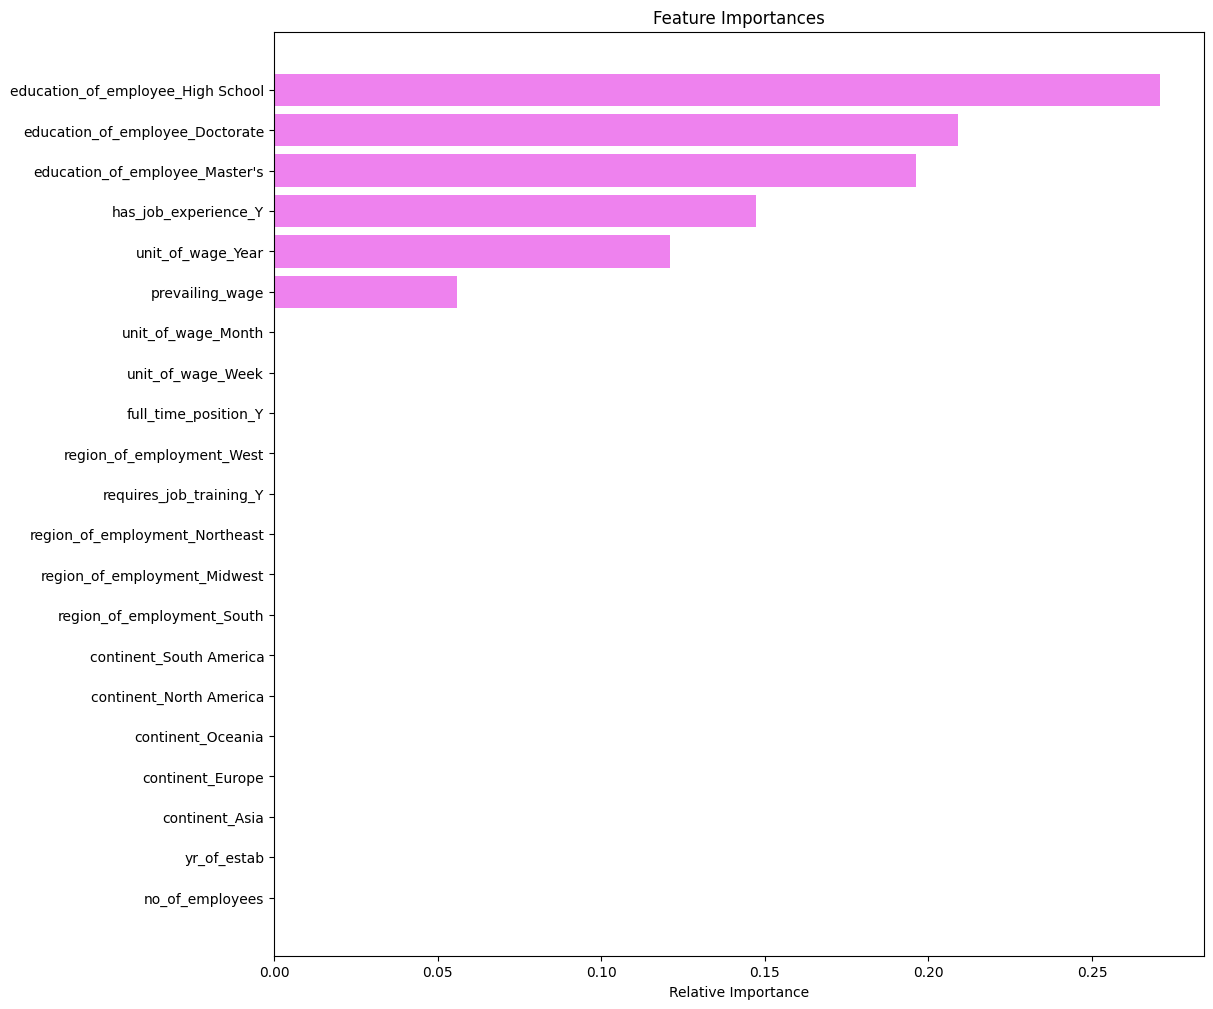

In [ ]:
feature_names = X_train.columns
importances = tuned_adb.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()



*  We can see that education_of_employee_High_School, education_of_employee_Doctorate, education_of_employee_Master's, has_job_experience_Y, unit_of_wage_Year are the most important features for making predictions.



**Actionable Insights & Recommendations**

**Insights**


*   The model shows a 0.71 precision, indicating moderate reliability.
*   Employees with higher education levels have a greater likelihood of obtaining a certified visa.
*   Employees with prior job experience also have a higher probability of receiving a certified visa.
*   Compared to other regions, the South and Midwest show a higher likelihood of certified visas.



**Recommendations**




*   The Office of Foreign Labor Certification (OFLC) can require employers to verify an applicant’s educational background and prior job experience before submitting a visa application.
*   Employers should hire candidates based on their yearly wage levels.
*   Employers should establish standardized wage levels that are consistent for both local and foreign employees.






